In [13]:
import pandas as pd

# --- Inputs ---
weights_file  = "average_nontarget_seed1_weights.txt"   # header=row4, weights=row6
features_file = "tcell100p_features_target.tsv"        # features start col D
output_file   = "scored_target_seed1.tsv"

# --- Step 1: Read header (row4) and weights (row6) ---
# Skip first 3 comment lines; pandas will read row4 as header, and we’ll then skip row5 to land on row6
wdf = pd.read_csv(weights_file, sep="\t", skiprows=3, nrows=1, header=0)
wdf.columns = wdf.columns.str.strip()

# Row 6 weights: read one more row after header row
weights_df = pd.read_csv(weights_file, sep="\t", skiprows=5, nrows=1, header=None)
weights_df.columns = wdf.columns  # assign correct headers

# --- Identify intercept ---
INTERCEPT_KEYS = {"m0", "intercept", "bias", "constant", "c", "(intercept)"}
intercept_cols = [c for c in weights_df.columns if c.strip().lower() in INTERCEPT_KEYS]

if not intercept_cols:
    raise ValueError("No intercept column found. Expected one of: " + ", ".join(sorted(INTERCEPT_KEYS)))

intercept_col = intercept_cols[-1]
intercept = float(weights_df.iloc[0][intercept_col])

# Extract feature weights (exclude intercept)
weights = {c: float(weights_df.iloc[0][c]) for c in weights_df.columns if c != intercept_col}

print(f"Intercept column: {intercept_col}  value={intercept}")
print(f"Feature weights read: {len(weights)}")

# --- Step 2: Read feature file ---
fdf = pd.read_csv(features_file, sep="\t")

# Ignore metadata columns (id, Label, ScanNr)
fdf_numeric = fdf.iloc[:, 3:].copy()
fdf_numeric.columns = fdf_numeric.columns.str.strip()

# --- Step 3: Match and compute ---
feature_cols = [c for c in weights if c in fdf_numeric.columns]
missing_in_features = [c for c in weights if c not in fdf_numeric.columns]

print(f"Overlapping features used: {len(feature_cols)}")
if missing_in_features:
    print("Missing feature columns (ignored):", missing_in_features)

# Coerce numeric, fill NaN with 0
X = fdf_numeric[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# Compute LDA score: dot + intercept
fdf["LDA_score"] = (X * [weights[c] for c in feature_cols]).sum(axis=1) + intercept

# --- Step 4: Write output ---
fdf.to_csv(output_file, sep="\t", index=False)
print(f"✅ Wrote: {output_file}")


Intercept column: m0  value=-0.435433
Feature weights read: 24
Overlapping features used: 24
✅ Wrote: scored_target_seed1.tsv


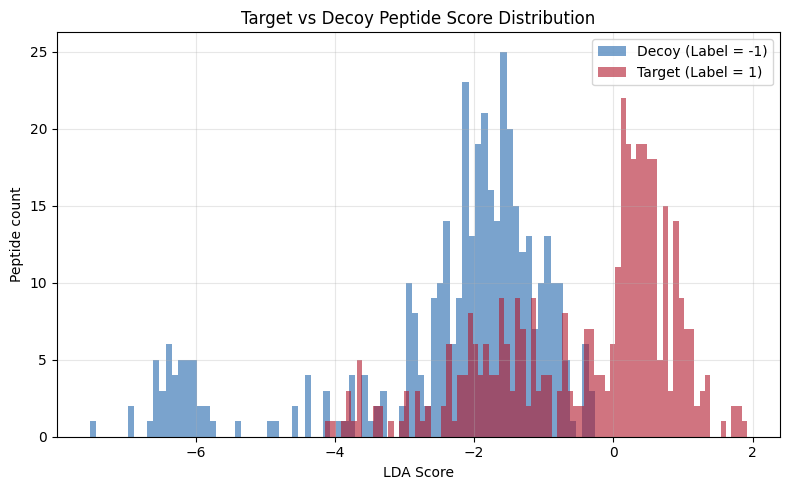

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Read scored file ---
df = pd.read_csv("scored_target_seed1.tsv", sep="\t")

# --- Extract columns ---
labels = df["Label"]
scores = df["LDA_score"]

# Split by label
target_scores = df.loc[labels == 1, "LDA_score"]
decoy_scores  = df.loc[labels == -1, "LDA_score"]

# --- Plot dual histogram ---
plt.figure(figsize=(8, 5))

plt.hist(decoy_scores, bins=80, color="#2166ac", alpha=0.6, label="Decoy (Label = -1)")
plt.hist(target_scores, bins=80, color="#b2182b", alpha=0.6, label="Target (Label = 1)")

plt.xlabel("LDA Score")
plt.ylabel("Peptide count")
plt.title("Target vs Decoy Peptide Score Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [17]:
import pandas as pd

df = pd.read_csv("scored_target_seed1.tsv", sep="\t")
df["Label"] = df["Label"].replace(-1, 0)
df.to_csv("scored_target_seed1_input.tsv", sep="\t", index=False)

print("✅ Wrote scored_target_seed1_label0.tsv with Label -1 → 0")


✅ Wrote scored_target_seed1_label0.tsv with Label -1 → 0
